# The Hidden Economy of IPL - A Descriptive Analysis (2008–2025)

## Objective
#### To uncover the rare moments that shape the outcome of a game.

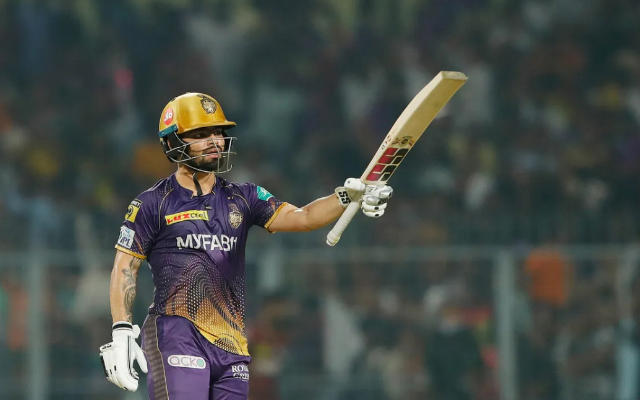

## Key Questions

### The Phase Baseline
How do scoring rates and risk profiles naturally evolve across the Powerplay, Middle, and Death overs? 

### The Pressure Pivot
At what point does a rising Required Run Rate (RRR) fundamentally alter the statistical behavior of the league? 

### The Performance Tax 
To what extent does high pressure "tax" a player's efficiency, and does this tax manifest as slower scoring or higher dismissal rates? 

### The Clutch-Impact Gap 
Which players consistently defy the league-wide "Pressure Tax" to deliver outsized returns when the game is on the line? 

### The Fate Decider: 
Do teams that win high-pressure moments consistently secure the match, or are these moments secondary to early-game dominance?

### _Starting with Exploring the data_
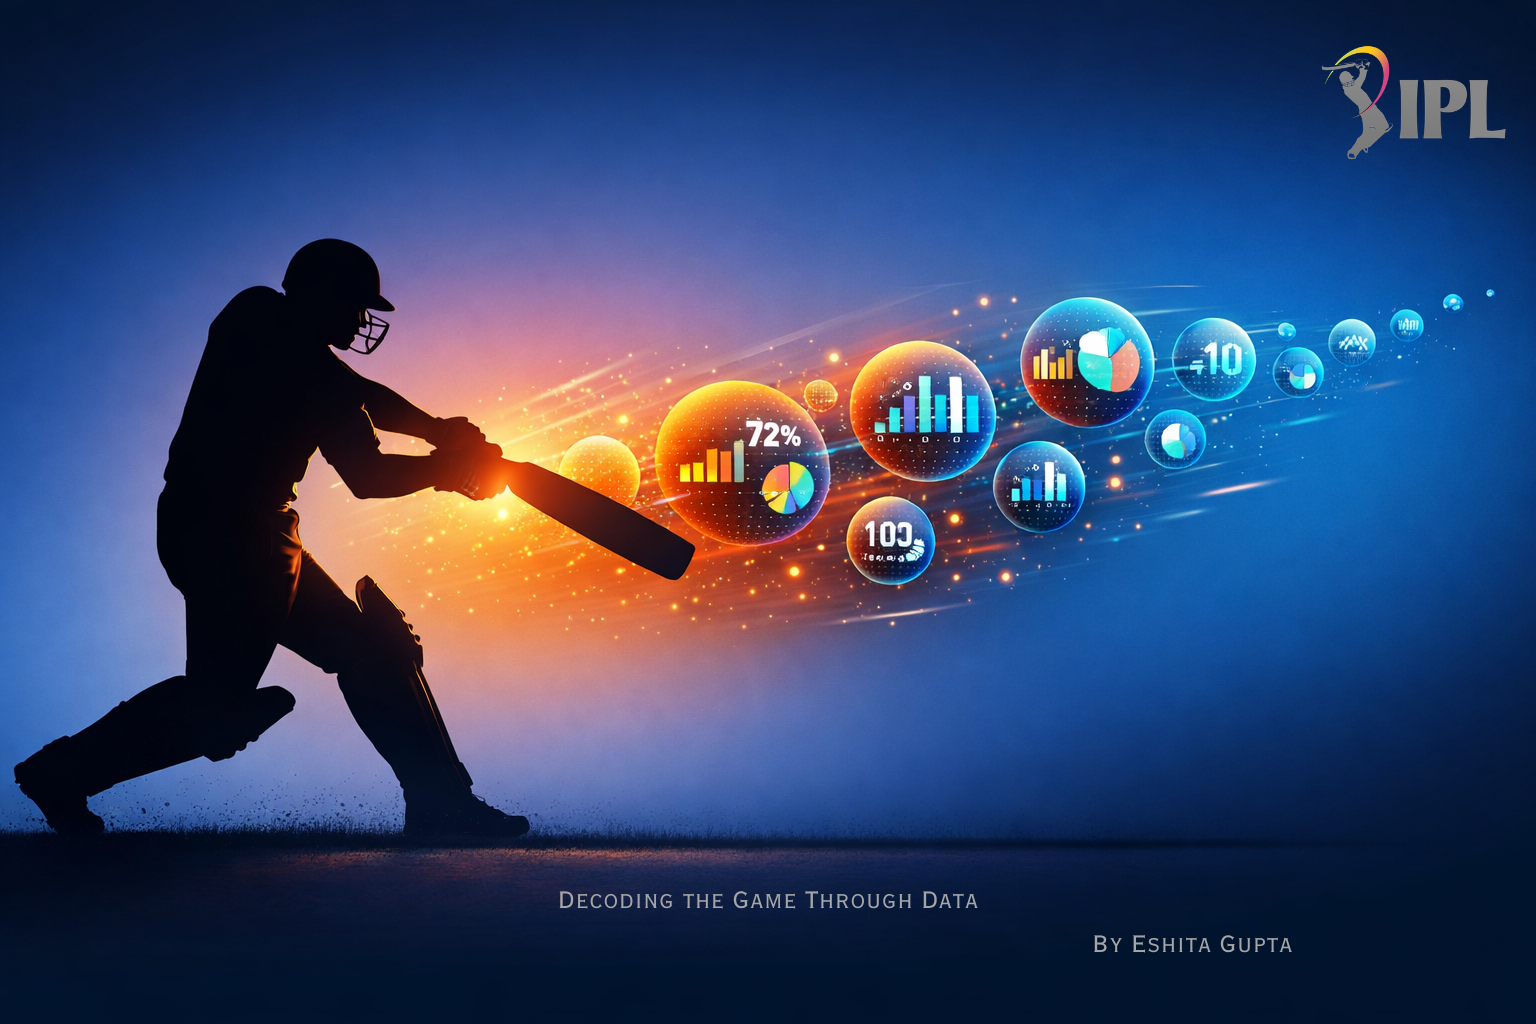

## Dataset Overview

We are working with multiple IPL datasets covering ball-by-ball and match-level information.

### Files:
1. IPL_ball_by_ball_updated.csv
2. deliveries_updated_ipl_upto_2025.csv
3. deliveries_updated_mens_ipl.csv
4. matches_updated_ipl_upto_2025.csv
5. matches_updated_mens_ipl.csv

In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

# Deliveries files
deliveries1 = pd.read_csv("data/IPL_ball_by_ball_updated.csv")
deliveries2 = pd.read_csv("data/deliveries_updated_ipl_upto_2025.csv")
deliveries3 = pd.read_csv("data/deliveries_updated_mens_ipl.csv")

# Matches files
match1 = pd.read_csv("data/matches_updated_ipl_upto_2025.csv")
match2 = pd.read_csv("data/matches_updated_mens_ipl.csv")

print("Data frames created")

Data frames created


In [4]:
# Comparing the files to make sure the data integrity is intact
print(""" 
------------------------------------------- 
Comparing shape of datasets
------------------------------------------- 
""")
print("Deliveries shapes:", deliveries1.shape, deliveries2.shape, deliveries3.shape)
print("Matches shapes:", match1.shape, match2.shape)

print(""" 
------------------------------------------- 
Comparing columns of datasets
------------------------------------------- 
""")
print(""" 
====================================== 
Columns of ball by ball data
====================================== 
""")
print("\nDeliveries columns:")
print("\ndeliveries1:", deliveries1.columns.tolist())
print("\ndeliveries2:", deliveries2.columns.tolist())
print("\ndeliveries3:", deliveries3.columns.tolist())

print("""
====================================== 
Columns of match level data
====================================== 
""")
print("\nMatches columns:")
print("\nmatch1:", match1.columns.tolist())
print("\nmatch2:", match2.columns.tolist())

# Head samples

print(""" 
-------------------------------------------
Printing a sample of data from each dataset
-------------------------------------------
""")
print("""
====================================== 
""")
print("\ndeliveries1 head:\n", deliveries1.sample(3))
print("""
====================================== 
""")
print("\ndeliveries2 head:\n", deliveries2.sample(3))
print("""
====================================== 
""")
print("\ndeliveries3 head:\n", deliveries3.sample(3))
print("""
====================================== 
""")
print("\nmatch1 head:\n", match1.sample(3))
print("""
====================================== 
""")
print("\nmatch2 head:\n", match2.sample(3))

 
------------------------------------------- 
Comparing shape of datasets
------------------------------------------- 

Deliveries shapes: (243815, 22) (278205, 20) (243817, 20)
Matches shapes: (1169, 28) (1024, 28)
 
------------------------------------------- 
Comparing columns of datasets
------------------------------------------- 

 
Columns of ball by ball data


Deliveries columns:

deliveries1: ['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']

deliveries2: ['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team', 'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty', 'dismissal_kind', 'player_dismissed', 'date']

deliveries3: ['matchId', 'inning', 'over_bal

#### _These datasets contain overlapping and partially duplicated information across different time ranges and formats so, we check the unique values, compare them and decide which dataset or combination of datasets to use._


In [5]:
# Standardize match ID column names (df1 uses match_id, df2/df3 use matchId) [cite: 206]
ids1 = set(deliveries1['match_id'].unique())
ids2 = set(deliveries2['matchId'].unique())
ids3 = set(deliveries3['matchId'].unique())

# Check intersections
print(f"Matches in File 1 & 2: {len(ids1.intersection(ids2))}")
print(f"Matches in File 2 & 3: {len(ids2.intersection(ids3))}")
print(f"Matches in File 1 & 3: {len(ids1.intersection(ids3))}")

# Check total unique matches across all three
all_ids = ids1.union(ids2).union(ids3)
print(f"Total unique matches across all files: {len(all_ids)}")

Matches in File 1 & 2: 1024
Matches in File 2 & 3: 1024
Matches in File 1 & 3: 1024
Total unique matches across all files: 1169


#### _Since there are 1,169 unique matches total, but each individual file only contains 1,024 matches (an overlap of 1,024 matches across all three), we combine them to capture the missing 145 matches. We are using deliveries2 as a standard and combining missing values into it._

In [6]:
# Standardize IDs
deliveries1 = deliveries1.rename(columns={'match_id': 'matchId'})

# 1. Identify which matches are missing from your primary file (df2)
# df2 has 1024 matches, but there are 1169 total. 
missing_from_deliveries2 = deliveries1[~deliveries1['matchId'].isin(deliveries2['matchId'])]

# 2. Standardize columns of the 'missing' data to match deliveries2's structure
# Map deliveries1 column names to deliveries2 column names
mapping = {
    'matchId': 'matchId',
    'innings': 'inning',
    'striker': 'batsman',
    'runs_off_bat': 'batsman_runs',
    'wicket_type': 'dismissal_kind',
    'start_date': 'date'
}
missing_standardized = missing_from_deliveries2.rename(columns=mapping)

# 3. Combine df2 with the missing records from df1
combined_deliveries = pd.concat([deliveries2, missing_standardized], ignore_index=True)

# 4. Final deduplication check
combined_deliveries = combined_deliveries.drop_duplicates(subset=['matchId', 'inning', 'over', 'ball'])

print(f"Final combined delivery count: {combined_deliveries.shape[0]}")
print(f"Unique matches in combined file: {combined_deliveries['matchId'].nunique()}")

Final combined delivery count: 278170
Unique matches in combined file: 1169


#### _We ensured all 1,169 matches are represented in ball-by-ball analysis for Integrity and consistency._

#### _Now we do a similar check for match level datasets._

In [7]:
# Get unique ID sets
set1 = set(match1['matchId'].unique())
set2 = set(match2['matchId'].unique())

# Results
print(f"Total Matches (Combined): {len(set1.union(set2))}")
print(f"Overlap: {len(set1.intersection(set2))}")
print(f"Missing if you use match1 only: {len(set2 - set1)}")
print(f"Missing if you use match2 only: {len(set1 - set2)}")

Total Matches (Combined): 1169
Overlap: 1024
Missing if you use match1 only: 0
Missing if you use match2 only: 145


#### _So now we have all 1,169 matches in our match level dataset, maintaining the Integrity and consistency._

## Let's dig into the data and analyse game phase by phase
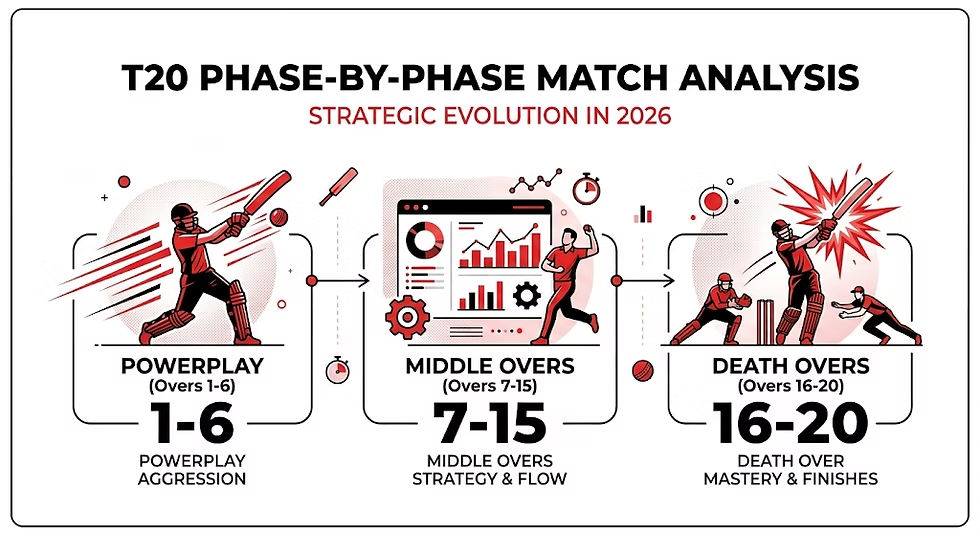

In [8]:
# Create total runs (batsman + extras)
deliveries2['total_runs'] = deliveries2['batsman_runs'] + deliveries2['extras']

# Define 'is_out' based on dismissal_kind
deliveries2['is_out'] = deliveries2['dismissal_kind'].notnull().astype(int)

In [9]:
# Define Phases
def get_phase(over):
    if over < 6: return '1. Powerplay (0-6)'
    elif over < 15: return '2. Middle (7-15)'
    else: return '3. Death (16-20)'

deliveries2['phase'] = deliveries2['over'].apply(get_phase)

# Calculate Baseline Stats per Phase
phase_baseline = deliveries2.groupby('phase').agg({
    'batsman_runs': 'mean',
    'is_out': 'mean'
}).rename(columns={'batsman_runs': 'Avg Runs/Ball', 'is_out': 'Wicket Probability'})

print("--- League Baseline by Phase ---")
print(phase_baseline)

--- League Baseline by Phase ---
                    Avg Runs/Ball  Wicket Probability
phase                                                
1. Powerplay (0-6)       1.203024            0.038641
2. Middle (7-15)         1.216593            0.041921
3. Death (16-20)         1.502528            0.080584


In [10]:
# 1. Cumulative runs per inning
deliveries2['current_score'] = deliveries2.groupby(['matchId', 'inning'])['total_runs'].cumsum()

# 2. Match Target (Total of 1st Innings)
targets = deliveries2[deliveries2['inning'] == 1].groupby('matchId')['total_runs'].sum().reset_index()
targets.columns = ['matchId', 'target']
deliveries2 = deliveries2.merge(targets, on='matchId', how='left')

# 3. Balls Remaining (assuming 20 over matches)
deliveries2['ball_count'] = deliveries2.groupby(['matchId', 'inning']).cumcount() + 1
deliveries2['balls_rem'] = (120 - deliveries2['ball_count']).clip(lower=1)

# 4. Required Run Rate (RRR) - only for 2nd innings
deliveries2['runs_rem'] = (deliveries2['target'] - deliveries2['current_score']).clip(lower=0)
deliveries2['rrr'] = (deliveries2['runs_rem'] * 6) / deliveries2['balls_rem']

# 5. Define Pressure Flag (RRR > 10 in 2nd Inning)
deliveries2['pressure_flag'] = 0
deliveries2.loc[(deliveries2['inning'] == 2) & (deliveries2['rrr'] > 10), 'pressure_flag'] = 1

# 6. Conclusion: The 19.8% Reality
pressure_pct = deliveries2['pressure_flag'].mean() * 100
print(f"\nConclusion: {pressure_pct:.1f}% of all deliveries occur in the 'Pressure Zone'.")


Conclusion: 19.8% of all deliveries occur in the 'Pressure Zone'.


In [11]:
# 1. Calculate stats for the Pressure Zone
pressure_stats = deliveries2.groupby('pressure_flag').agg({
    'batsman_runs': 'mean',
    'is_out': 'mean'
}).rename(columns={'batsman_runs': 'Avg Runs/Ball', 'is_out': 'Wicket Probability'})

print("--- Normal Zone (0) vs. Pressure Zone (1) ---")
print(pressure_stats)

# 2. Calculate the 'Pressure Tax' (Percentage Change)
tax = pressure_stats.pct_change().iloc[1] * 100
print(f"\nUnder Pressure, the risk of a wicket increases by: {tax['Wicket Probability']:.1f}%")

--- Normal Zone (0) vs. Pressure Zone (1) ---
               Avg Runs/Ball  Wicket Probability
pressure_flag                                   
0                   1.277180            0.045481
1                   1.278181            0.066750

Under Pressure, the risk of a wicket increases by: 46.8%


While the league naturally accelerates in the Death phase to 1.5 runs/ball, the 'Pressure Zone' forces a 47% increase in risk just to maintain a competitive presence.

This is the mathematical proof that the game changes fundamentally in those rare moments.

### _The Pressure zone analytics_

In [16]:
# Ensure match IDs are compatible
deliveries2['matchId'] = deliveries2['matchId'].astype(int)
match1['matchId'] = match1['matchId'].astype(int)

# Join winner and outcome info to every ball
df = deliveries2.merge(match1[['matchId', 'winner', 'team1', 'team2', 'season']], 
                     left_on='matchId', right_on='matchId', how='left')

# Define 'is_out' and 'is_winning_team'
df['is_out'] = df['dismissal_kind'].notnull().astype(int)
df['is_winning_team'] = (df['batting_team'] == df['winner']).astype(int)

# --- Q1: The Phase Baseline ---
# This shows the 'Natural' state of the game
q1_baseline = df.groupby('phase').agg({
    'batsman_runs': 'mean',
    'is_out': 'mean'
}).rename(columns={'batsman_runs': 'Runs_Per_Ball', 'is_out': 'Wicket_Prob'})

# --- Q2: The Pressure Pivot ---
# Let's see how risk jumps as RRR increases (2nd innings only)
df['rrr_bin'] = pd.cut(df['rrr'], bins=[0, 6, 8, 10, 12, 15, 20])
q2_pivot = df[df['inning'] == 2].groupby('rrr_bin', observed=True)['is_out'].mean()

# --- Q3: The Performance Tax ---
# Comparing Normal vs Pressure states
q3_tax = df.groupby('pressure_flag').agg({
    'batsman_runs': 'mean',
    'is_out': 'mean'
})

# --- Q4: The Clutch-Impact Gap (Player Level) ---
player_clutch = df.groupby(['batsman', 'pressure_flag']).agg({
    'batsman_runs': 'sum',
    'ball_count': 'count'
}).reset_index()
player_clutch['sr'] = (player_clutch['batsman_runs'] / player_clutch['ball_count']) * 100

# Create the gap
gap_df = player_clutch.pivot(index='batsman', columns='pressure_flag', values='sr')
gap_df['clutch_gap'] = gap_df[1] - gap_df[0]
top_clutch = gap_df[gap_df.index.isin(player_clutch[player_clutch['ball_count'] > 50]['batsman'])].sort_values('clutch_gap', ascending=False)

# --- Q5: The Fate Decider ---
# Did the team batting in the 'Pressure Zone' win the match?
q5_fate = df[df['pressure_flag'] == 1].groupby('matchId')['is_winning_team'].max().mean()

# Export for Tableau
df.to_csv("tableau_ready_ipl.csv", index=False)
print("csv file downloaded")

csv file downloaded
